# PyPSA Network Comparative Analysis

This notebook provides a modular framework for comparing multiple solved PyPSA networks. 
It includes helper functions for:
- Loading networks and building metadata tables
- Safely extracting optimized vs. installed capacities
- Computing snapshot weighting in hours
- Checking component availability in networks

**Purpose:** Comparative analysis of solved network runs (not optimization)

## Section 1: Imports and Configuration

In [27]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, Tuple, Optional, List, Union
import warnings
from matplotlib.colors import Normalize, TwoSlopeNorm
import cartopy.crs as ccrs


# Configure display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress warnings for cleaner output (optional)
warnings.filterwarnings('ignore', category=FutureWarning)

In [28]:
# Helper: parse network label into components and utility to add columns to a dataframe

def split_network_name(s: str):
    """Return (scenario_name, transmission_setting, wind_condition) from label.

    Handles labels like:
      - germany_{scenario_name}-{transmission}_{wind}
      - germany_{scenario_name}_{wind}    (assumes transmission='fixed')
      - {scenario_name}-{transmission}_{wind}
    """
    s = str(s)
    if s.startswith('germany_'):
        rem = s[len('germany_'):]
    else:
        rem = s
    # default values
    wind = ''
    transmission = 'fixed'
    scenario_name = rem
    # extract wind (last underscore)
    if '_' in rem:
        rem_no_wind, wind = rem.rsplit('_', 1)
    else:
        rem_no_wind = rem
    # extract transmission (dash)
    if '-' in rem_no_wind:
        scenario_name, transmission = rem_no_wind.split('-', 1)
    else:
        scenario_name = rem_no_wind
        transmission = 'fixed'
    return scenario_name, transmission, wind


def add_split_columns(df, scenario_col='scenario'):
    """Add `scenario_name`, `transmission_setting`, `wind_condition` to DataFrame in-place and return it."""
    if scenario_col not in df.columns:
        return df
    vals = [split_network_name(x) for x in df[scenario_col].astype(str)]
    scen_names, trans, winds = zip(*vals)
    df = df.copy()
    df['scenario_name'] = list(scen_names)
    df['transmission_setting'] = list(trans)
    df['wind_condition'] = list(winds)
    print(df)
    return df


In [29]:
# Configuration constants (centralized)
OUTPUT_DIR = Path("/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv")
CONGESTION_THRESHOLD = 60.0
TOP_N_LINES = 5
TOP_N_BUSES = 5
SHEDDING_CARRIER_REGEX = "load"  # used with pandas .str.contains
SNAPSHOT_HOURS = 1.0  # assume uniform hourly snapshots

# Verbosity control
VERBOSE = True

# Ensure output directory exists
try:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
except Exception:
    pass

In [30]:
# Consolidated component-check helpers and snapshot-hours helper
def has_generators(n: pypsa.Network) -> bool:
    return not getattr(n, 'generators', pd.DataFrame()).empty

def has_lines(n: pypsa.Network) -> bool:
    return not getattr(n, 'lines', pd.DataFrame()).empty

def has_loads(n: pypsa.Network) -> bool:
    return not getattr(n, 'loads', pd.DataFrame()).empty

def has_buses(n: pypsa.Network) -> bool:
    return not getattr(n, 'buses', pd.DataFrame()).empty

def has_links(n: pypsa.Network) -> bool:
    return not getattr(n, 'links', pd.DataFrame()).empty

def has_stores(n: pypsa.Network) -> bool:
    return not getattr(n, 'stores', pd.DataFrame()).empty

def split_run_key(run_key: Union[Tuple[str, str, str], str]) -> Tuple[str, Optional[str], Optional[str]]:
    """Normalize run keys from either tuple or string format."""
    if isinstance(run_key, tuple) and len(run_key) == 3:
        scenario, wind_condition, transmission_setting = run_key
        return str(scenario), str(wind_condition), str(transmission_setting)
    return str(run_key), None, None

def format_run_label(run_key: Union[Tuple[str, str, str], str]) -> str:
    """Create a readable label from normalized run key parts."""
    scenario, wind_condition, transmission_setting = split_run_key(run_key)
    if wind_condition is None and transmission_setting is None:
        return scenario
    return f"{scenario} / {wind_condition} / {transmission_setting}"

def snapshot_hours(network: pypsa.Network) -> pd.Series:
    """Return a pd.Series of snapshot hours aligned to network.snapshots."""
    try:
        return pd.Series(SNAPSHOT_HOURS, index=network.snapshots)
    except Exception:
        # Fallback: return ones with length equal to snapshots
        return pd.Series(np.ones(len(getattr(network, 'snapshots', []))) * SNAPSHOT_HOURS,
                         index=getattr(network, 'snapshots', []))

## Section 2: Define Results Folder and Network Dictionary

The solved networks are stored in a nested directory structure:
```
/home/lucakristin/Desktop/my_pypsa/pypsa-eur/results/
├── germany_base2_notwindy/
│   └── networks/
│       └── base_s_450_elec_.nc
├── germany_baseTP_windvariability/
│   └── networks/
│       └── base_s_450_elec_.nc
└── ...
```

Networks are loaded into a dictionary with tuple keys: `(scenario_name, wind_condition, transmission_setting)`

In [31]:
# Define the base results directory
RESULTS_DIR = Path("/home/lucakristin/Desktop/my_pypsa/pypsa-eur/results")
NETWORK_FILENAME = "base_s_450_elec_.nc"
NETWORKS_SUBFOLDER = "networks"

def parse_network_directory_name(dir_name: str) -> Optional[str]:
    """
    Parse a network directory name to get the scenario identifier.
    
    Assumes directory names follow the pattern: germany_{scenario_name}
    
    Parameters
    ----------
    dir_name : str
        Directory name (e.g., 'germany_base2_notwindy')
    
    Returns
    -------
    str or None
        The directory name itself if it starts with 'germany_', otherwise None.
    """
    if not dir_name.startswith("germany_"):
        return None
    
    return dir_name


def load_networks_from_results(
    results_dir: Path = RESULTS_DIR,
    network_filename: str = NETWORK_FILENAME,
    networks_subfolder: str = NETWORKS_SUBFOLDER
) -> Dict[str, pypsa.Network]:
    """
    Load all available solved networks from the results directory.
    
    Parameters
    ----------
    results_dir : Path
        Base results directory containing scenario subdirectories
    network_filename : str
        Name of the network file (default: 'base_s_450_elec_.nc')
    networks_subfolder : str
        Subfolder name containing network files (default: 'networks')
    
    Returns
    -------
    Dict[str, pypsa.Network]
        Dictionary with scenario name as key.
    """
    networks = {}
    
    for scenario_dir in sorted(results_dir.iterdir()):
        if not scenario_dir.is_dir():
            continue
        
        # Parse the directory name
        scenario_name = parse_network_directory_name(scenario_dir.name)
        if scenario_name is None:
            continue
        
        # Check if network file exists
        network_path = scenario_dir / networks_subfolder / network_filename
        if not network_path.exists():
            print(f"[WARNING] Network file not found: {network_path}")
            continue
        
        try:
            network = pypsa.Network()
            network.import_from_netcdf(str(network_path))
            networks[scenario_name] = network
            print(f"[INFO] Loaded network for scenario: {scenario_name}")
        except Exception as e:
            print(f"[ERROR] {e}")
    return networks

# Load networks
networks = load_networks_from_results()

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)


[INFO] Loaded network for scenario: germany_base2_notwindy


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


[INFO] Loaded network for scenario: germany_base2_windvariability


INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)


...

[INFO] Loaded network for scenario: germany_scenario2040-fixed_notwindy


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)


[INFO] Loaded network for scenario: germany_scenario2040-fixed_windvariability


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


[INFO] Loaded network for scenario: germany_scenario2040-fixed_windy


In [32]:
print(networks)

{'germany_base2_notwindy': PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1350
 - Carrier: 27
 - Generator: 4592
 - GlobalConstraint: 2
 - Line: 628
 - Link: 1800
 - Load: 450
 - StorageUnit: 60
 - Store: 900
 - SubNetwork: 1
Snapshots: 24
, 'germany_base2_windvariability': PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1350
 - Carrier: 27
 - Generator: 4592
 - GlobalConstraint: 2
 - Line: 628
 - Link: 1800
 - Load: 450
 - StorageUnit: 60
 - Store: 900
 - SubNetwork: 1
Snapshots: 24
, 'germany_base2_windy': PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1350
 - Carrier: 27
 - Generator: 4592
 - GlobalConstraint: 2
 - Line: 628
 - Link: 1800
 - Load: 450
 - StorageUnit: 60
 - Store: 900
 - SubNetwork: 1
Snapshots: 24
, 'germany_scenario2040-TP_notwindy': PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1350
 - Carrier: 27
 - Generator: 4655
 -

In [33]:
# --- Define the normalization for the color map ---
NORMAL_PRICE = 93.15
HIGH_PRICE_THRESHOLD = 10000

# We find the global min and max across all scenarios for a consistent color scale
all_peak_prices = []
for n in networks.values():
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    all_peak_prices.append(n.buses_t.marginal_price.loc[peak_price_time])
global_min = pd.concat(all_peak_prices).min()
global_max = pd.concat(all_peak_prices).max()

# Create a diverging normalization centered on the "normal" price
# Ensure vcenter is strictly between vmin and vmax.
# The main scale will go up to the high price threshold.
vmin = min(global_min, NORMAL_PRICE)
vmax = min(global_max, HIGH_PRICE_THRESHOLD)

# Adjust vmin and vmax to ensure vcenter is not at the boundary
if vmin >= NORMAL_PRICE:
    vmin = NORMAL_PRICE - 1 
if vmax <= NORMAL_PRICE:
    vmax = NORMAL_PRICE + 1

marginal_price_norm = TwoSlopeNorm(
    vcenter=NORMAL_PRICE, vmin=vmin, vmax=vmax
)

print(vmin, NORMAL_PRICE, vmax)

# Get the colormap and set the color for values over the threshold
cmap = plt.get_cmap('RdYlGn_r').copy()
cmap.set_over('blue')

-32.34203267754546 93.15 10000


## Section 3: Build Network Run Metadata DataFrame

In [34]:
def build_metadata_dataframe(
    networks: Dict[str, pypsa.Network]
) -> pd.DataFrame:
    """
    Build a metadata DataFrame from the networks dictionary.
    
    Parameters
    ----------
    networks : Dict[str, pypsa.Network]
        Dictionary of loaded networks with scenario name as key.
    
    Returns
    -------
    pd.DataFrame
        Metadata for all runs with columns:
        - scenario_name
        - n_snapshots
        - n_buses
        - n_generators
        - n_lines
        - n_loads
        - n_links
        - n_stores
        - objective
    """
    metadata = []
    
    for scenario_name, network in networks.items():
        # Get network statistics
        n_snapshots = len(network.snapshots)
        n_buses = len(network.buses)
        n_generators = len(network.generators)
        n_lines = len(network.lines)
        n_loads = len(network.loads)
        n_links = len(network.links)
        n_stores = len(network.stores)
        
        # Get objective value if network was solved
        objective = getattr(network, 'objective', np.nan)
        
        metadata.append({
            'scenario_name': scenario_name,
            'n_snapshots': n_snapshots,
            'n_buses': n_buses,
            'n_generators': n_generators,
            'n_lines': n_lines,
            'n_loads': n_loads,
            'n_links': n_links,
            'n_stores': n_stores,
            'objective': objective,
        })
    
    return pd.DataFrame(metadata)


# Build and display metadata DataFrame
runs_metadata = build_metadata_dataframe(networks)
print("Network Run Metadata:")
print(runs_metadata.to_string())
print(f"\nTotal runs: {len(runs_metadata)}")


Network Run Metadata:
                                  scenario_name  n_snapshots  n_buses  n_generators  n_lines  n_loads  n_links  n_stores     objective
0                        germany_base2_notwindy           24     1350          4592      628      450     1800       900  2.091066e+07
1                 germany_base2_windvariability           24     1350          4592      628      450     1800       900  1.827415e+07
2                           germany_base2_windy           24     1350          4592      628      450     1800       900  3.287647e+06
3              germany_scenario2040-TP_notwindy           24     1350          4655      642      450     1818       900  3.583695e+07
4       germany_scenario2040-TP_windvariability           24     1350          4655      642      450     1818       900  2.976762e+08
5                 germany_scenario2040-TP_windy           24     1350          4655      642      450     1818       900  1.433934e+06
6          germany_scenario2040-e

## Section 4: Safely Retrieve Optimized or Installed Capacities

Helper functions to extract capacity data, with fallback logic for when optimized values are not available.
Remember: `s_nom` is the original nominal value, `s_nom_opt` is the optimized value after solving.

In [35]:
def get_generator_capacities(
    network: pypsa.Network,
    use_optimized: bool = True
) -> pd.DataFrame:
    """
    Extract generator capacities with fallback logic.
    
    Returns p_nom_opt if available and use_optimized=True, otherwise p_nom.
    
    Parameters
    ----------
    network : pypsa.Network
        PyPSA network object
    use_optimized : bool
        If True, prefer p_nom_opt; if False, use p_nom
    
    Returns
    -------
    pd.DataFrame
        Generator data with columns: ['p_nom', 'p_nom_opt', 'capacity_used']
        The 'capacity_used' column contains the effective capacity being used.
    """
    if network.generators.empty:
        return pd.DataFrame()
    
    capacity_df = network.generators[['p_nom']].copy()
    
    # Add optimized capacity if available
    if 'p_nom_opt' in network.generators.columns:
        capacity_df['p_nom_opt'] = network.generators['p_nom_opt']
    else:
        capacity_df['p_nom_opt'] = np.nan
    
    # Determine which capacity is being used
    if use_optimized and 'p_nom_opt' in network.generators.columns:
        capacity_df['capacity_used'] = network.generators['p_nom_opt']
    else:
        capacity_df['capacity_used'] = network.generators['p_nom']
    
    return capacity_df


def get_line_capacities(
    network: pypsa.Network,
    use_optimized: bool = True
) -> pd.DataFrame:
    """
    Extract line capacities with fallback logic.
    
    Returns s_nom_opt if available and use_optimized=True, otherwise s_nom.
    
    Parameters
    ----------
    network : pypsa.Network
        PyPSA network object
    use_optimized : bool
        If True, prefer s_nom_opt; if False, use s_nom
    
    Returns
    -------
    pd.DataFrame
        Line data with columns: ['s_nom', 's_nom_opt', 'capacity_used']
        The 'capacity_used' column contains the effective capacity being used.
    """
    if network.lines.empty:
        return pd.DataFrame()
    
    capacity_df = network.lines[['s_nom']].copy()
    
    # Add optimized capacity if available
    if 's_nom_opt' in network.lines.columns:
        capacity_df['s_nom_opt'] = network.lines['s_nom_opt']
    else:
        capacity_df['s_nom_opt'] = np.nan
    
    # Determine which capacity is being used
    if use_optimized and 's_nom_opt' in network.lines.columns:
        capacity_df['capacity_used'] = network.lines['s_nom_opt']
    else:
        capacity_df['capacity_used'] = network.lines['s_nom']
    
    return capacity_df


def get_link_capacities(
    network: pypsa.Network,
    use_optimized: bool = True
) -> pd.DataFrame:
    """
    Extract link capacities with fallback logic.
    
    Returns p_nom_opt if available and use_optimized=True, otherwise p_nom.
    
    Parameters
    ----------
    network : pypsa.Network
        PyPSA network object
    use_optimized : bool
        If True, prefer p_nom_opt; if False, use p_nom
    
    Returns
    -------
    pd.DataFrame
        Link data with columns: ['p_nom', 'p_nom_opt', 'capacity_used']
    """
    if network.links.empty:
        return pd.DataFrame()
    
    capacity_df = network.links[['p_nom']].copy()
    
    # Add optimized capacity if available
    if 'p_nom_opt' in network.links.columns:
        capacity_df['p_nom_opt'] = network.links['p_nom_opt']
    else:
        capacity_df['p_nom_opt'] = np.nan
    
    # Determine which capacity is being used
    if use_optimized and 'p_nom_opt' in network.links.columns:
        capacity_df['capacity_used'] = network.links['p_nom_opt']
    else:
        capacity_df['capacity_used'] = network.links['p_nom']
    
    return capacity_df


def get_store_capacities(
    network: pypsa.Network,
    use_optimized: bool = True
) -> pd.DataFrame:
    """
    Extract store (energy storage) capacities with fallback logic.
    
    Returns e_nom_opt if available and use_optimized=True, otherwise e_nom.
    
    Parameters
    ----------
    network : pypsa.Network
        PyPSA network object
    use_optimized : bool
        If True, prefer e_nom_opt; if False, use e_nom
    
    Returns
    -------
    pd.DataFrame
        Store data with columns: ['e_nom', 'e_nom_opt', 'capacity_used']
    """
    if network.stores.empty:
        return pd.DataFrame()
    
    capacity_df = network.stores[['e_nom']].copy()
    
    # Add optimized capacity if available
    if 'e_nom_opt' in network.stores.columns:
        capacity_df['e_nom_opt'] = network.stores['e_nom_opt']
    else:
        capacity_df['e_nom_opt'] = np.nan
    
    # Determine which capacity is being used
    if use_optimized and 'e_nom_opt' in network.stores.columns:
        capacity_df['capacity_used'] = network.stores['e_nom_opt']
    else:
        capacity_df['capacity_used'] = network.stores['e_nom']
    
    return capacity_df


# Example: Extract generator capacities from first network
if networks:
    first_network = next(iter(networks.values()))
    gen_caps = get_generator_capacities(first_network, use_optimized=True)
    print("Generator Capacities (first 5 rows):")
    print(gen_caps.head() if not gen_caps.empty else "No generators found")


Generator Capacities (first 5 rows):
                   p_nom  p_nom_opt  capacity_used
name                                              
DE0 0 OCGT      13.57003   13.57003       13.57003
DE0 0 biomass  153.65800  153.65800      153.65800
DE0 0 oil        4.16800    4.16800        4.16800
DE0 0 waste      0.59000    0.59000        0.59000
DE0 1 OCGT       1.68400    1.68400        1.68400


## Section 7: Compute Network Summaries for Comparative Analysis

In [36]:
# Use consolidated component helper functions defined above: has_loads, has_generators, has_lines, etc.

def compute_network_summary(
    network: pypsa.Network,
    scenario_name: str,
    wind_condition: Optional[str] = None,
    transmission_setting: Optional[str] = None
) -> Dict[str, Union[str, float, int]]:
    """
    Compute a one-row summary for a solved PyPSA network.

    Robust to missing data and various network configurations.
    """
    summary = {
        'scenario': scenario_name,
    }
    if wind_condition is not None:
        summary['wind_condition'] = wind_condition
    if transmission_setting is not None:
        summary['transmission_setting'] = transmission_setting

    # Get snapshot weights for proper weighting (uniform hours)
    snapshot_weights = snapshot_hours(network)

    # =====================================================================
    # LOAD STATISTICS
    # =====================================================================

    # Total demand input in MWh (loads_t.p_set is the input set-point time series)
    if has_loads(network) and hasattr(network, 'loads_t') and hasattr(network.loads_t, 'p_set') and not network.loads_t.p_set.empty:
        total_load = (network.loads_t.p_set.sum(axis=1) * snapshot_weights).sum()
    else:
        total_load = np.nan
    summary['load_served_MWh'] = total_load

    # Load shedding in MWh (if available)
    load_shedding = np.nan
    if has_generators(network) and 'carrier' in network.generators.columns:
        load_shed_mask = network.generators['carrier'].astype(str).str.lower() == 'load'
        load_shed_gens = network.generators.index[load_shed_mask]
        if len(load_shed_gens) > 0 and hasattr(network, 'generators_t') and hasattr(network.generators_t, 'p') and not network.generators_t.p.empty:
            available_cols = [g for g in load_shed_gens if g in network.generators_t.p.columns]
            if available_cols:
                shed_output = network.generators_t.p[available_cols].sum(axis=1)
                load_shedding = (shed_output * snapshot_weights).sum()
    summary['load_shedding_MWh'] = load_shedding

    # =====================================================================
    # MARGINAL PRICE STATISTICS
    # =====================================================================

    avg_marginal_price = np.nan
    max_marginal_price = np.nan

    if hasattr(network, 'buses_t') and hasattr(network.buses_t, 'marginal_price'):
        marginal_prices = network.buses_t.marginal_price
        if not marginal_prices.empty:
            # Flatten and remove NaN values
            flat_prices = marginal_prices.values.flatten()
            flat_prices = flat_prices[~np.isnan(flat_prices)]

            if len(flat_prices) > 0 and snapshot_weights.sum() > 0:
                # For each snapshot, average across buses, then weight snapshots
                avg_by_snapshot = marginal_prices.mean(axis=1)
                avg_marginal_price = (avg_by_snapshot * snapshot_weights).sum() / snapshot_weights.sum()
                max_marginal_price = flat_prices.max()

    summary['avg_marginal_price'] = avg_marginal_price
    summary['max_marginal_price'] = max_marginal_price

    # =====================================================================
    # CO2 EMISSIONS
    # =====================================================================

    total_co2 = np.nan

    # Try to get CO2 emissions using carrier-level emissions (carriers.co2_emissions)
    if has_generators(network) and hasattr(network, 'generators_t'):
        if hasattr(network.generators_t, 'p') and not network.generators_t.p.empty:
            gen_output = network.generators_t.p  # snapshots x generators

            # Prefer carrier-level emissions stored in network.carriers['co2_emissions']
            carriers = getattr(network, 'carriers', pd.DataFrame())
            if not carriers.empty and 'co2_emissions' in carriers.columns and 'carrier' in network.generators.columns:
                try:
                    emissions_by_carrier = carriers['co2_emissions'].fillna(0)
                    emissions = network.generators['carrier'].map(emissions_by_carrier).fillna(0)
                    hourly_co2 = (gen_output * emissions).sum(axis=1)
                    total_co2 = (hourly_co2 * snapshot_weights).sum()
                except Exception:
                    total_co2 = np.nan

    summary['total_co2_emissions'] = total_co2

    # =====================================================================
    # LINE LOADING STATISTICS
    # =====================================================================

    avg_line_loading = np.nan
    max_line_loading = np.nan
    lines_above_60pct = 0
    lines_above_70pct = 0

    if has_lines(network) and hasattr(network, 'lines_t') and hasattr(network.lines_t, 'p0'):
        line_power = network.lines_t.p0  # snapshots x lines

        # Use optimized line capacities when available, fallback to nominal
        if 's_nom_opt' in network.lines.columns:
            line_capacity = network.lines['s_nom_opt'].fillna(network.lines['s_nom'])
        else:
            line_capacity = network.lines['s_nom']

        # Keep only lines that exist in flow table and have positive capacity
        valid_lines = [ln for ln in line_power.columns if ln in line_capacity.index and pd.notna(line_capacity.loc[ln]) and line_capacity.loc[ln] > 0]

        if valid_lines and snapshot_weights.sum() > 0:
            loading_matrix = np.abs(line_power[valid_lines].values) / line_capacity.loc[valid_lines].values

            # Average loading per line across snapshots (weighted by snapshot weights)
            avg_loading_per_line = (loading_matrix.T * snapshot_weights.values).sum(axis=1) / snapshot_weights.sum()

            # Overall statistics
            avg_line_loading = float(avg_loading_per_line.mean() * 100.0)
            max_line_loading = float(loading_matrix.max() * 100.0)

            # Count lines above thresholds
            lines_above_60pct = int((avg_loading_per_line > 0.60).sum())
            lines_above_70pct = int((avg_loading_per_line > 0.70).sum())

    summary['avg_line_loading_pct'] = avg_line_loading
    summary['max_line_loading_pct'] = max_line_loading
    summary['lines_above_60pct'] = lines_above_60pct
    summary['lines_above_70pct'] = lines_above_70pct

    return summary


print("Computing network summaries...")
summary_data = []

for run_key, network in networks.items():
    # Support both key styles:
    # 1) tuple -> (scenario, wind_condition, transmission_setting)
    # 2) str   -> scenario name only
    if isinstance(run_key, tuple) and len(run_key) == 3:
        scenario_name, wind_condition, transmission_setting = run_key
    else:
        scenario_name = str(run_key)
        wind_condition = None
        transmission_setting = None

    try:
        row_summary = compute_network_summary(
            network=network,
            scenario_name=scenario_name,
            wind_condition=wind_condition,
            transmission_setting=transmission_setting,
        )
        summary_data.append(row_summary)
    except Exception as e:
        print(f"[ERROR] Failed to compute summary for {run_key}: {e}")

# Create comprehensive summary DataFrame
if summary_data:
    summary_df = pd.DataFrame(summary_data)

    # Reorder columns for readability
    col_order = [
        'scenario', 'wind_condition', 'transmission_setting',
        'load_served_MWh', 'load_shedding_MWh',
        'avg_marginal_price', 'max_marginal_price',
        'total_co2_emissions',
        'avg_line_loading_pct', 'max_line_loading_pct',
        'lines_above_60pct', 'lines_above_70pct',
    ]

    # Select only columns that exist
    col_order = [c for c in col_order if c in summary_df.columns]
    summary_df = summary_df[col_order]

    print(f"\n[OK] Computed summaries for {len(summary_df)} networks")
    print("\nNetwork Summary DataFrame:")
    print(summary_df.to_string(index=False))
else:
    print("[ERROR] No summaries could be computed")
    summary_df = pd.DataFrame()

Computing network summaries...

[OK] Computed summaries for 15 networks

Network Summary DataFrame:
                                   scenario  load_served_MWh  load_shedding_MWh  avg_marginal_price  max_marginal_price  total_co2_emissions  avg_line_loading_pct  max_line_loading_pct  lines_above_60pct  lines_above_70pct
                     germany_base2_notwindy     1.300023e+06           0.016149           54.523992          143.429463        179627.348282             11.849893             69.135637                  0                  0
              germany_base2_windvariability     1.368958e+06           0.010292           41.099507         1112.255027        162112.501269             17.016474             69.135542                  1                  0
                        germany_base2_windy     1.179665e+06           0.001492           14.581968          253.915883         36931.243746             15.521747             69.491919                  4                  0
        

## Section 8: Line-Level Congestion Statistics

In [37]:
# Use consolidated has_lines helper defined in the utilities cell above

def compute_line_congestion_stats(network: pypsa.Network) -> pd.DataFrame:
    """
    Compute line-level congestion statistics for a solved network.
    
    Parameters
    ----------
    network : pypsa.Network
        Solved PyPSA network
    
    Returns
    -------
    pd.DataFrame
        One row per line with columns:
        - line_id: index name of the line
        - bus0: source bus
        - bus1: target bus
        - average_loading_pct: weighted average loading across all snapshots
        - max_loading_pct: maximum instantaneous loading
        - hours_above_60: number of weighted hours with loading > 60%
        - hours_above_70: number of weighted hours with loading > 70%
    """
    if not has_lines(network):
        return pd.DataFrame()
    
    if not hasattr(network, 'lines_t') or not hasattr(network.lines_t, 'p0'):
        return pd.DataFrame()
    
    # Get line power flows and capacities
    line_flows = network.lines_t.p0  # snapshots x lines
    
    # Determine which capacity to use (optimized or original)
    if 's_nom_opt' in network.lines.columns:
        line_capacity = network.lines['s_nom_opt'].copy()
        # Handle any NaN values in optimized capacity
        line_capacity.fillna(network.lines['s_nom'], inplace=True)
    else:
        line_capacity = network.lines['s_nom'].copy()
    
    # Get snapshot weights (uniform hourly snapshots)
    snapshot_weights = snapshot_hours(network)
    
    # Build results
    results = []
    
    for line_idx in network.lines.index:
        line_row = network.lines.loc[line_idx]
        
        # Get capacity, handle zero or NaN
        capacity = line_capacity.loc[line_idx]
        if np.isnan(capacity) or capacity <= 0:
            # Skip lines with invalid capacity
            continue
        
        # Get power flow for this line
        if line_idx in line_flows.columns:
            flow = line_flows[line_idx].values
        else:
            continue
        
        # Calculate loading as absolute flow / capacity
        loading = np.abs(flow) / capacity
        
        # Calculate statistics
        avg_loading = (loading * snapshot_weights.values).sum() / snapshot_weights.sum()
        max_loading = loading.max()
        
        # Count hours above thresholds
        hours_above_60 = ((loading > 0.60) * snapshot_weights.values).sum()
        hours_above_70 = ((loading > 0.70) * snapshot_weights.values).sum()
        
        results.append({
            'line_id': line_idx,
            'bus0': line_row['bus0'],
            'bus1': line_row['bus1'],
            'average_loading_pct': avg_loading * 100,
            'max_loading_pct': max_loading * 100,
            'hours_above_60': hours_above_60,
            'hours_above_70': hours_above_70,
        })
    
    return pd.DataFrame(results)


def get_top_loaded_lines(
    line_stats: pd.DataFrame,
    n: int = 10,
    sort_by: str = 'average_loading_pct'
) -> pd.DataFrame:
    """
    Get the top N most loaded lines from congestion statistics.
    
    Parameters
    ----------
    line_stats : pd.DataFrame
        Output from compute_line_congestion_stats()
    n : int
        Number of top lines to return (default: 10)
    sort_by : str
        Column to sort by (default: 'average_loading_pct')
        Options: 'average_loading_pct', 'max_loading_pct', 'hours_above_70', etc.
    
    Returns
    -------
    pd.DataFrame
        Top N lines sorted by the specified metric
    """
    if line_stats.empty:
        return pd.DataFrame()
    
    if sort_by not in line_stats.columns:
        print(f"[WARNING] Column '{sort_by}' not found. Using 'average_loading_pct'")
        sort_by = 'average_loading_pct'
    
    return line_stats.nlargest(n, sort_by)


# Build line statistics dictionary for all networks
line_stats_by_run = {}

for run_key, network in networks.items():
    run_label = format_run_label(run_key)
    try:
        line_stats = compute_line_congestion_stats(network)
        line_stats_by_run[run_key] = line_stats
    except Exception as e:
        print(f"[ERROR] Failed for {run_label}: {e}")
        line_stats_by_run[run_key] = pd.DataFrame()

# Example: Show top 5 most loaded lines from first network
if line_stats_by_run:
    first_key = next(iter(line_stats_by_run.keys()))
    first_stats = line_stats_by_run[first_key]
    
    if not first_stats.empty:
        print(f"\nTop 5 most loaded lines for {format_run_label(first_key)}:")
        top_lines = get_top_loaded_lines(first_stats, n=TOP_N_LINES, sort_by='average_loading_pct')
        print(top_lines.to_string(index=False))
    else:
        print(f"No line data available for {format_run_label(first_key)}")



Top 5 most loaded lines for germany_base2_notwindy:
line_id    bus0    bus1  average_loading_pct  max_loading_pct  hours_above_60  hours_above_70
     99  DE0 13  DE0 69            52.282781        52.282791             0.0             0.0
    169 DE0 156  DE0 48            51.613062        69.135637             9.0             0.0
    168 DE0 156  DE0 22            49.922787        66.520782             5.0             0.0
    235  DE0 18 DE0 282            42.173621        47.533739             0.0             0.0
    248 DE0 184 DE0 329            40.832678        56.011876             0.0             0.0


## Section 9: Bus-Level Stress Statistics

In [38]:
def compute_bus_stress_stats(network: pypsa.Network) -> pd.DataFrame:
    """
    Compute bus-level stress statistics for a solved network.

    Only buses with positive load shedding are returned.
    """
    if network.buses.empty:
        return pd.DataFrame()

    marginal_prices = None
    if hasattr(network, 'buses_t') and hasattr(network.buses_t, 'marginal_price'):
        if not network.buses_t.marginal_price.empty:
            marginal_prices = network.buses_t.marginal_price

    if network.generators.empty or 'carrier' not in network.generators.columns:
        return pd.DataFrame()

    load_mask = network.generators.carrier.str.contains(SHEDDING_CARRIER_REGEX, case=False, na=False)
    shed_gens = network.generators.index[load_mask]

    if len(shed_gens) == 0:
        return pd.DataFrame()

    if not hasattr(network, 'generators_t') or not hasattr(network.generators_t, 'p'):
        return pd.DataFrame()

    available_shed_gens = [gen for gen in shed_gens if gen in network.generators_t.p.columns]
    if len(available_shed_gens) == 0:
        return pd.DataFrame()

    shed_output = network.generators_t.p[available_shed_gens].fillna(0)
    shed_bus = network.generators.loc[available_shed_gens, 'bus']
    shed_by_bus = shed_output.groupby(shed_bus, axis=1).sum()

    total_shedding_by_bus = shed_by_bus.sum(axis=0)
    positive_buses = total_shedding_by_bus[total_shedding_by_bus > 0]

    if positive_buses.empty:
        return pd.DataFrame()

    max_shedding_by_bus = shed_by_bus.max(axis=0)
    worst_snapshot_by_bus = shed_by_bus.idxmax(axis=0)

    results = []
    for bus_id, total_load_shedding_mwh in positive_buses.items():
        bus_row = network.buses.loc[bus_id] if bus_id in network.buses.index else pd.Series(dtype=float)

        if marginal_prices is not None and bus_id in marginal_prices.columns:
            prices = marginal_prices[bus_id].dropna()
            average_marginal_price = prices.mean() if not prices.empty else np.nan
            max_marginal_price = prices.max() if not prices.empty else np.nan
        else:
            average_marginal_price = np.nan
            max_marginal_price = np.nan

        results.append({
            'bus_id': bus_id,
            'x': bus_row['x'] if 'x' in bus_row else np.nan,
            'y': bus_row['y'] if 'y' in bus_row else np.nan,
            'average_marginal_price': average_marginal_price,
            'max_marginal_price': max_marginal_price,
            'total_load_shedding_mwh': float(total_load_shedding_mwh),
            'max_load_shedding_mw': float(max_shedding_by_bus.loc[bus_id]),
            'worst_shedding_snapshot': worst_snapshot_by_bus.loc[bus_id],
        })

    bus_stats = pd.DataFrame(results)
    if not bus_stats.empty:
        bus_stats = bus_stats.sort_values('total_load_shedding_mwh', ascending=False).reset_index(drop=True)
    return bus_stats


def get_top_buses_by_price(
    bus_stats: pd.DataFrame,
    n: int = 10,
    price_metric: str = 'average_marginal_price'
) -> pd.DataFrame:
    """
    Get the top N buses by marginal price.
    """
    if bus_stats.empty:
        return pd.DataFrame()

    if price_metric not in bus_stats.columns:
        print(f"[WARNING] Column '{price_metric}' not found. Using 'average_marginal_price'")
        price_metric = 'average_marginal_price'

    valid_data = bus_stats[bus_stats[price_metric].notna()]
    if valid_data.empty:
        return pd.DataFrame()

    return valid_data.nlargest(n, price_metric)


def get_top_buses_by_load_shedding(
    bus_stats: pd.DataFrame,
    n: int = 10,
    shedding_metric: str = 'total_load_shedding_mwh'
) -> pd.DataFrame:
    """
    Get the top N buses by load shedding.
    """
    if bus_stats.empty:
        return pd.DataFrame()

    if shedding_metric not in bus_stats.columns:
        print(f"[WARNING] Column '{shedding_metric}' not found. Using 'total_load_shedding_mwh'")
        shedding_metric = 'total_load_shedding_mwh'

    valid_data = bus_stats[bus_stats[shedding_metric].notna()]
    if valid_data.empty:
        return pd.DataFrame()

    return valid_data.nlargest(n, shedding_metric)


# Build bus statistics dictionary for all networks
print("Computing bus-level stress statistics...")
bus_stats_by_run = {}

for run_key, network in networks.items():
    run_label = format_run_label(run_key)
    try:
        bus_stats = compute_bus_stress_stats(network)
        if bus_stats.empty:
            print(f"[OK] {run_label}: 0 buses with shedding")
            continue

        bus_stats_by_run[run_key] = bus_stats
        print(f"[OK] {run_label}: {len(bus_stats)} buses with shedding")
    except Exception as e:
        print(f"[ERROR] Failed for {run_label}: {e}")

print(f"\n[OK] Computed bus statistics for {len(bus_stats_by_run)} runs")

# Example: Show top buses by price and shedding from first network
if bus_stats_by_run:
    first_key = next(iter(bus_stats_by_run.keys()))
    first_stats = bus_stats_by_run[first_key]

    if not first_stats.empty:
        print(f"\n[INFO] Bus stress statistics for {format_run_label(first_key)}:")

        top_price = get_top_buses_by_price(first_stats, n=5, price_metric='average_marginal_price')
        if not top_price.empty:
            print("\nTop 5 buses by average marginal price:")
            print(top_price[['bus_id', 'average_marginal_price', 'max_marginal_price']].to_string(index=False))

        top_shedding = get_top_buses_by_load_shedding(first_stats, n=5, shedding_metric='total_load_shedding_mwh')
        if not top_shedding.empty:
            print("\nTop 5 buses by load shedding:")
            print(top_shedding[['bus_id', 'total_load_shedding_mwh', 'max_load_shedding_mw', 'worst_shedding_snapshot']].to_string(index=False))
        else:
            print("\nNo load shedding detected in this network")
    else:
        print(f"No bus data available for {format_run_label(first_key)}")


Computing bus-level stress statistics...
[OK] germany_base2_notwindy: 1350 buses with shedding
[OK] germany_base2_windvariability: 1350 buses with shedding
[OK] germany_base2_windy: 1350 buses with shedding
[OK] germany_scenario2040-TP_notwindy: 1350 buses with shedding
[OK] germany_scenario2040-TP_windvariability: 1350 buses with shedding
[OK] germany_scenario2040-TP_windy: 1350 buses with shedding
[OK] germany_scenario2040-ext-TP_notwindy: 1350 buses with shedding
[OK] germany_scenario2040-ext-TP_windvariability: 1350 buses with shedding
[OK] germany_scenario2040-ext-TP_windy: 1350 buses with shedding
[OK] germany_scenario2040-ext_notwindy: 1350 buses with shedding
[OK] germany_scenario2040-ext_windvariability: 1350 buses with shedding
[OK] germany_scenario2040-ext_windy: 1350 buses with shedding
[OK] germany_scenario2040-fixed_notwindy: 1350 buses with shedding
[OK] germany_scenario2040-fixed_windvariability: 1350 buses with shedding
[OK] germany_scenario2040-fixed_windy: 1350 buses

In [39]:
# Section 9.0: Curtailment calculation by carrier and run
# Builds `curtailment_df` before Section 9.1 uses it.


def compute_curtailment_by_carrier(network: pypsa.Network) -> pd.DataFrame:
    """Compute carrier-level available, dispatched, and curtailed power for one network.

    Uses generator carrier grouping and treats snapshots as uniform hourly samples.
    Returns one row per carrier with run-independent metrics.
    """
    if not has_generators(network):
        return pd.DataFrame()

    if not hasattr(network, 'generators_t') or not hasattr(network.generators_t, 'p'):
        return pd.DataFrame()

    if not hasattr(network.generators_t, 'p_max_pu'):
        return pd.DataFrame()

    gens = network.generators
    p_max_pu = network.generators_t.p_max_pu
    p = network.generators_t.p

    available_gens = [g for g in gens.index if g in p_max_pu.columns and g in p.columns]
    if not available_gens:
        return pd.DataFrame()

    gens = gens.loc[available_gens]
    p_max_pu = p_max_pu[available_gens].fillna(0)
    p = p[available_gens].fillna(0)

    # Instantaneous available power (MW) and dispatched power (MW)
    p_available = p_max_pu.multiply(gens['p_nom'], axis=1)
    p_available_by_carrier = p_available.T.groupby(gens['carrier']).sum().T
    p_by_carrier = p.T.groupby(gens['carrier']).sum().T
    p_curtailed_by_carrier = (p_available_by_carrier - p_by_carrier).clip(lower=0)

    # Convert snapshots to hours (uniform 1h snapshots by default)
    hours = snapshot_hours(network)
    hours = hours.reindex(p_available_by_carrier.index).fillna(SNAPSHOT_HOURS)

    rows = []
    for carrier in p_available_by_carrier.columns:
        available_ts = p_available_by_carrier[carrier]
        dispatched_ts = p_by_carrier[carrier]
        curtailed_ts = p_curtailed_by_carrier[carrier]

        total_available = float((available_ts * hours).sum())
        total_dispatched = float((dispatched_ts * hours).sum())
        total_curtailed = float((curtailed_ts * hours).sum())
        capacity = float(gens.groupby('carrier')['p_nom'].sum().get(carrier, np.nan))

        rows.append({
            'carrier': carrier,
            'available_mwh': total_available,
            'dispatched_mwh': total_dispatched,
            'curtailed_mwh': total_curtailed,
            'capacity_mw': capacity,
            'curtailment_share_pct': (total_curtailed / total_available * 100.0) if total_available > 0 else np.nan,
        })

    curtailment = pd.DataFrame(rows)
    if not curtailment.empty:
        curtailment = curtailment.sort_values('curtailed_mwh', ascending=False).reset_index(drop=True)
    return curtailment


def build_curtailment_dataframe(
    networks: Dict[Union[Tuple[str, str, str], str], pypsa.Network]
) -> pd.DataFrame:
    """Build a long-format curtailment dataframe across all runs."""
    rows = []
    for run_key, network in networks.items():
        scenario, wind_condition, transmission_setting = split_run_key(run_key)
        curtailment = compute_curtailment_by_carrier(network)
        if curtailment.empty:
            continue

        curtailment = curtailment.copy()
        curtailment['scenario'] = scenario
        curtailment['wind_condition'] = wind_condition
        curtailment['transmission_setting'] = transmission_setting
        
        rows.append(curtailment[curtailment['curtailment_share_pct'].notnull()])

    if not rows:
        return pd.DataFrame()

    curtailment_df = pd.concat(rows, ignore_index=True)
    # Put run identifiers first for readability
    run_cols = ['scenario', 'wind_condition', 'transmission_setting']
    other_cols = [c for c in curtailment_df.columns if c not in run_cols]
    return curtailment_df[run_cols + other_cols]


curtailment_df = build_curtailment_dataframe(networks)
if not curtailment_df.empty:
    print(f"Curtailment rows: {len(curtailment_df)}")
    display(curtailment_df.head(10))
else:
    print("No curtailment data found in the loaded networks.")

Curtailment rows: 60


,scenario,wind_condition,transmission_setting,carrier,available_mwh,dispatched_mwh,curtailed_mwh,capacity_mw,curtailment_share_pct
0,germany_base2_notwindy,None,None,solar,4.381812e+05,438048.790985,132.373984,86408.000000,0.030210
1,germany_base2_notwindy,None,None,ror,6.387188e+04,63869.595498,2.288049,4014.118709,0.003582
2,germany_base2_notwindy,None,None,onwind,4.943540e+04,49434.998816,0.398832,73332.065900,0.000807
3,germany_base2_notwindy,None,None,offwind-ac,8.316630e+03,8316.624031,0.005567,11163.743000,0.000067
4,germany_base2_windvariability,None,None,onwind,8.048308e+05,627686.430574,177144.367827,73332.065900,22.010138
5,germany_base2_windvariability,None,None,offwind-ac,1.735688e+05,69168.049141,104400.711874,11163.743000,60.149483
6,germany_base2_windvariability,None,None,solar,9.012128e+04,83814.861702,6306.415752,86408.000000,6.997699
7,germany_base2_windvariability,None,None,ror,2.621926e+04,26076.924715,142.338338,4014.118709,0.542877
8,germany_base2_windy,None,None,onwind,1.520776e+06,891757.662632,629018.541018,73332.065900,41.361677
9,germany_base2_windy,None,None,offwind-ac,2.362175e+05,37499.900053,198717.580295,11163.743000,84.124841


## Section 9.1: Final comparison tables (run-level and long-format aggregations)
Creates: `summary_df` (ensures), `curtailment_report` (run-aggregated), `top_lines_all_runs_df` (long-format top congested lines), `top_buses_all_runs_df` (long-format top stressed buses)

In [40]:
from typing import List

# helper to ensure run columns exist on a dataframe
def _ensure_run_cols(df: pd.DataFrame, scenario, wind, trans) -> pd.DataFrame:
    df = df.copy()
    if 'scenario' not in df.columns:
        df['scenario'] = scenario
    if 'wind_condition' not in df.columns:
        df['wind_condition'] = wind
    if 'transmission_setting' not in df.columns:
        df['transmission_setting'] = trans
    # keep column order common for readability
    run_cols = ['scenario', 'wind_condition', 'transmission_setting']
    other_cols = [c for c in df.columns if c not in run_cols]
    return df[run_cols + other_cols]

# 1) summary_df (ensure it exists and contains run identifiers)
if 'summary_df' in globals():
    summary_df = summary_df.copy()
else:
    if 'summary_data' in globals() and summary_data:
        summary_df = pd.DataFrame(summary_data)
    else:
        summary_df = pd.DataFrame()

for col in ['scenario', 'wind_condition', 'transmission_setting']:
    if col not in summary_df.columns:
        summary_df[col] = np.nan

# 2) curtailment_report: aggregate numeric curtailment metrics per run
curtailment_report = pd.DataFrame()
if 'curtailment_df' in globals():
    curtailment_report = curtailment_df.copy()
    # Ensure run cols exist (if individual rows already include them they are kept)
    for col in ['scenario', 'wind_condition', 'transmission_setting']:
        if col not in curtailment_report.columns:
            curtailment_report[col] = np.nan

    # Aggregate numeric metrics per run
    numeric = curtailment_report.select_dtypes(include=[np.number]).columns.tolist()
    if numeric:
        agg = curtailment_report.groupby(['scenario', 'wind_condition', 'transmission_setting'])[numeric].sum().reset_index()
        curtailment_report = agg
        # Create a pivot (scenario x transmission_setting with wind_condition as columns) for quick comparison if possible
    else:
        # no numeric columns to aggregate; keep original
        curtailment_report = curtailment_report

# 3) long-format dataframe of top congested lines across all runs
top_lines_all_runs_df = pd.DataFrame()
_line_rows: List[pd.DataFrame] = []
if 'line_stats_by_run' in globals():
    for run_key, df in line_stats_by_run.items():
        if df is None or df.empty:
            continue
        scenario, wind, trans = split_run_key(run_key)
        tmp = _ensure_run_cols(df, scenario, wind, trans)
        # choose sorting column
        sort_col = 'average_loading_pct' if 'average_loading_pct' in tmp.columns else ('max_loading_pct' if 'max_loading_pct' in tmp.columns else None)
        if sort_col is not None:
            try:
                top = tmp.nlargest(TOP_N_LINES, sort_col)
            except Exception:
                top = tmp.sort_values(sort_col, ascending=False).head(TOP_N_LINES)
        else:
            top = tmp.head(TOP_N_LINES)
        _line_rows.append(top)
    if _line_rows:
        top_lines_all_runs_df = pd.concat(_line_rows, ignore_index=True)

# 4) long-format dataframe of top stressed buses across all runs
top_buses_all_runs_df = pd.DataFrame()
_bus_rows: List[pd.DataFrame] = []
if 'bus_stats_by_run' in globals():
    for run_key, df in bus_stats_by_run.items():
        if df is None or df.empty:
            continue
        scenario, wind, trans = split_run_key(run_key)
        tmp = _ensure_run_cols(df, scenario, wind, trans)
        sort_col = 'total_load_shedding_mwh' if 'total_load_shedding_mwh' in tmp.columns else ('average_marginal_price' if 'average_marginal_price' in tmp.columns else None)
        if sort_col is not None:
            try:
                topb = tmp.nlargest(TOP_N_BUSES, sort_col)
            except Exception:
                topb = tmp.sort_values(sort_col, ascending=False).head(TOP_N_BUSES)
        else:
            topb = tmp.head(TOP_N_BUSES)
        _bus_rows.append(topb)
    if _bus_rows:
        top_buses_all_runs_df = pd.concat(_bus_rows, ignore_index=True)

# Make outputs easy to inspect and export
# expose variables with stable names the rest of the notebook expects
final_summary_df = summary_df
final_curtailment_report = curtailment_report
final_top_lines = top_lines_all_runs_df
final_top_buses = top_buses_all_runs_df

print('Final comparison tables created:')
print(' - final_summary_df:', final_summary_df.shape)
print(' - final_curtailment_report:', final_curtailment_report.shape)
print(' - final_top_lines:', final_top_lines.shape)
print(' - final_top_buses:', final_top_buses.shape)

# Display small previews for quick inspection
if not final_summary_df.empty:
    print('\nSummary (first 5 rows):')
    display(final_summary_df.head())
if not final_curtailment_report.empty:
    print('\nCurtailment report (first 5 rows):')
    display(final_curtailment_report.head())
if not final_top_lines.empty:
    print('\nTop congested lines (first 10 rows):')
    display(final_top_lines.head(10))
if not final_top_buses.empty:
    print('\nTop stressed buses (first 10 rows):')
    display(final_top_buses.head(10))


Final comparison tables created:
 - final_summary_df: (15, 12)
 - final_curtailment_report: (0, 8)
 - final_top_lines: (75, 10)
 - final_top_buses: (75, 11)

Summary (first 5 rows):


,scenario,load_served_MWh,load_shedding_MWh,avg_marginal_price,max_marginal_price,total_co2_emissions,avg_line_loading_pct,max_line_loading_pct,lines_above_60pct,lines_above_70pct,wind_condition,transmission_setting
0,germany_base2_notwindy,1.300023e+06,0.016149,54.523992,143.429463,179627.348282,11.849893,69.135637,0,0,NaN,NaN
1,germany_base2_windvariability,1.368958e+06,0.010292,41.099507,1112.255027,162112.501269,17.016474,69.135542,1,0,NaN,NaN
2,germany_base2_windy,1.179665e+06,0.001492,14.581968,253.915883,36931.243746,15.521747,69.491919,4,0,NaN,NaN
3,germany_scenario2040-TP_notwindy,2.042893e+06,1023.733863,70.090914,10000.009907,31342.377636,16.145011,69.561525,5,0,NaN,NaN
4,germany_scenario2040-TP_windvariability,2.151220e+06,26935.808215,1043.432942,10000.010692,77053.853429,21.349600,69.597970,20,0,NaN,NaN



Top congested lines (first 10 rows):


,scenario,wind_condition,transmission_setting,line_id,bus0,bus1,average_loading_pct,max_loading_pct,hours_above_60,hours_above_70
0,germany_base2_notwindy,None,None,99,DE0 13,DE0 69,52.282781,52.282791,0.0,0.0
1,germany_base2_notwindy,None,None,169,DE0 156,DE0 48,51.613062,69.135637,9.0,0.0
2,germany_base2_notwindy,None,None,168,DE0 156,DE0 22,49.922787,66.520782,5.0,0.0
3,germany_base2_notwindy,None,None,235,DE0 18,DE0 282,42.173621,47.533739,0.0,0.0
4,germany_base2_notwindy,None,None,248,DE0 184,DE0 329,40.832678,56.011876,0.0,0.0
5,germany_base2_windvariability,None,None,98,DE0 13,DE0 329,62.648676,62.735194,24.0,0.0
6,germany_base2_windvariability,None,None,248,DE0 184,DE0 329,57.200027,59.038233,0.0,0.0
7,germany_base2_windvariability,None,None,169,DE0 156,DE0 48,56.388385,69.135542,11.0,0.0
8,germany_base2_windvariability,None,None,622,DE0 61,DE0 96,56.221647,68.236158,15.0,0.0
9,germany_base2_windvariability,None,None,60,DE0 115,DE0 46,54.697321,64.688843,10.0,0.0



Top stressed buses (first 10 rows):


,scenario,wind_condition,transmission_setting,bus_id,x,y,average_marginal_price,max_marginal_price,total_load_shedding_mwh,max_load_shedding_mw,worst_shedding_snapshot
0,germany_base2_notwindy,None,None,DE0 190 H2,8.445451,48.986082,138.754434,138.754459,0.000012,5.027005e-07,2025-04-08 10:00:00
1,germany_base2_notwindy,None,None,DE0 190 battery,8.445451,48.986082,134.063611,140.521243,0.000012,5.027943e-07,2025-04-08 06:00:00
2,germany_base2_notwindy,None,None,DE0 190,8.445451,48.986082,134.036391,143.429463,0.000012,5.029429e-07,2025-04-08 06:00:00
3,germany_base2_notwindy,None,None,DE0 191 H2,8.680719,51.996842,87.725996,87.726028,0.000012,5.001084e-07,2025-04-08 03:00:00
4,germany_base2_notwindy,None,None,DE0 116 H2,8.641451,48.890160,80.960342,80.960374,0.000012,4.997671e-07,2025-04-08 11:00:00
5,germany_base2_windvariability,None,None,DE0 386,9.073516,49.311935,1087.356683,1112.255027,0.000009,3.559919e-07,2025-10-06 11:00:00
6,germany_base2_windvariability,None,None,DE0 386 battery,9.073516,49.311935,1081.924673,1089.772269,0.000009,3.550970e-07,2025-10-06 11:00:00
7,germany_base2_windvariability,None,None,DE0 386 H2,9.073516,49.311935,1044.767340,1044.767341,0.000008,3.532795e-07,2025-10-06 10:00:00
8,germany_base2_windvariability,None,None,DE0 190,8.445451,48.986082,580.964537,598.289026,0.000008,3.365628e-07,2025-10-06 10:00:00
9,germany_base2_windvariability,None,None,DE0 190 battery,8.445451,48.986082,578.465628,586.190829,0.000008,3.361330e-07,2025-10-06 10:00:00


## Section 10: Cross-Network Bottleneck Analysis

In [41]:
def build_cross_network_bottlenecks(
    line_stats_by_run: Dict,
    networks: Dict[Union[Tuple[str, str, str], str], pypsa.Network],
    congestion_threshold: float = CONGESTION_THRESHOLD
) -> pd.DataFrame:
    """
    Identify bottleneck lines across multiple network runs.
    
    Parameters
    ----------
    line_stats_by_run : Dict
        Dictionary with keys (scenario, wind_condition, transmission_setting)
        and values as DataFrames from compute_line_congestion_stats()
    networks : Dict[Tuple[str, str, str], pypsa.Network]
        Dictionary of PyPSA networks
    congestion_threshold : float
        Loading percentage threshold to identify congestion (default: 60.0)
    
    Returns
    -------
    pd.DataFrame
        Cross-network bottleneck summary with columns:
        - line_id, bus0, bus1
        - number_of_networks_congested
        - list_of_networks_congested
        - average_loading_across_networks
        - maximum_loading_across_networks
        - loading_change_vs_fixed_case (if fixed case available)
        - line_length, x_coordinate, y_coordinate (if available)
        - carrier (if available)
        - region (if available)
    
    Notes
    -----
    The "fixed case" is identified as the reference scenario with transmission_setting='fixed'.
    Congestion is determined per run, then aggregated across runs.
    """
    
    # Helper function to create readable run name
    def make_run_name(scenario: str, wind: Optional[str], transmission: Optional[str]) -> str:
        if wind is None and transmission is None:
            return scenario
        return f"{scenario}_{wind}_{transmission}"
    
    # Collect congested lines from each run
    all_congested = []
    
    for run_key, line_stats in line_stats_by_run.items():
        if line_stats.empty:
            continue
        
        scenario, wind, transmission = split_run_key(run_key)
        run_name = make_run_name(scenario, wind, transmission)
        
        # Find congested lines in this run
        congested = line_stats[line_stats['average_loading_pct'] >= congestion_threshold].copy()
        
        if len(congested) > 0:
            congested['run_name'] = run_name
            congested['scenario'] = scenario
            congested['wind_condition'] = wind
            congested['transmission_setting'] = transmission
            all_congested.append(congested)
    
    if not all_congested:
        print("[WARNING] No congested lines found at this threshold")
        return pd.DataFrame()
    
    # Combine all congested lines
    combined = pd.concat(all_congested, ignore_index=True)
    
    # Group by line_id and aggregate
    bottlenecks = []
    
    for line_id in combined['line_id'].unique():
        line_data = combined[combined['line_id'] == line_id]
        
        bottleneck = {
            'line_id': line_id,
            'bus0': line_data['bus0'].iloc[0],
            'bus1': line_data['bus1'].iloc[0],
            'number_of_networks_congested': len(line_data),
            'list_of_networks_congested': ', '.join(sorted(line_data['run_name'].unique())),
            'average_loading_across_networks': line_data['average_loading_pct'].mean(),
            'maximum_loading_across_networks': line_data['average_loading_pct'].max(),
            'min_loading_across_networks': line_data['average_loading_pct'].min(),
        }
        
        # Find loading change vs fixed case
        fixed_case_loadings = line_data[
            line_data['transmission_setting'] == 'fixed'
        ]['average_loading_pct']
        
        if len(fixed_case_loadings) > 0:
            fixed_loading = fixed_case_loadings.iloc[0]
            other_loadings = line_data[
                line_data['transmission_setting'] != 'fixed'
            ]['average_loading_pct']
            
            if len(other_loadings) > 0:
                bottleneck['loading_change_vs_fixed'] = other_loadings.mean() - fixed_loading
            else:
                bottleneck['loading_change_vs_fixed'] = np.nan
        else:
            bottleneck['loading_change_vs_fixed'] = np.nan
        
        bottlenecks.append(bottleneck)
    
    bottleneck_df = pd.DataFrame(bottlenecks)
    
    # =====================================================================
    # ADD ADDITIONAL COLUMNS FROM NETWORK DATA
    # =====================================================================
    
    # Get reference network (first available) to extract line metadata
    if networks:
        ref_network = next(iter(networks.values()))
        
        # Add line metadata if available
        
        if not ref_network.lines.empty:
            line_meta = {}
            
            for line_id in ref_network.lines.index:
                meta = {
                    'line_length': np.nan,
                    'x_coordinate': np.nan,
                    'y_coordinate': np.nan,
                    'carrier': 'AC',
                }
                
                # Try to extract length
                if 'length' in ref_network.lines.columns:
                    meta['line_length'] = ref_network.lines.loc[line_id, 'length']
                
                # Try to extract carrier
                if 'carrier' in ref_network.lines.columns:
                    meta['carrier'] = ref_network.lines.loc[line_id, 'carrier']
                
                # Try to get bus coordinates
                try:
                    bus0_idx = ref_network.lines.loc[line_id, 'bus0']
                    
                    if bus0_idx in ref_network.buses.index:
                        bus0 = ref_network.buses.loc[bus0_idx]
                        if 'x' in bus0 and 'y' in bus0:
                            meta['bus0_x'] = bus0['x']
                            meta['bus0_y'] = bus0['y']
                        if 'country' in bus0:
                            meta['country'] = bus0['country']
                except Exception:
                    pass
                
                line_meta[line_id] = meta
            
            # Merge metadata into bottleneck dataframe
            meta_df = pd.DataFrame(line_meta).T
            bottleneck_df = bottleneck_df.merge(
                meta_df,
                left_on='line_id',
                right_index=True,
                how='left'
            )
    
    # =====================================================================
    # SORT AND REORDER COLUMNS FOR REPORT
    # =====================================================================
    
    # Sort by number of networks (desc) then average loading (desc)
    bottleneck_df = bottleneck_df.sort_values(
        by=['number_of_networks_congested', 'average_loading_across_networks'],
        ascending=[False, False]
    ).reset_index(drop=True)
    
    # Reorder columns for readability
    priority_cols = [
        'line_id', 'bus0', 'bus1',
        'number_of_networks_congested',
        'list_of_networks_congested',
        'average_loading_across_networks',
        'maximum_loading_across_networks',
        'min_loading_across_networks',
        'loading_change_vs_fixed',
    ]
    
    optional_cols = [
        'line_length', 'carrier',
        'bus0_x', 'bus0_y',
        'country', 'x_coordinate', 'y_coordinate'
    ]
    
    # Select columns that exist
    col_order = [c for c in priority_cols if c in bottleneck_df.columns]
    col_order += [c for c in optional_cols if c in bottleneck_df.columns]
    col_order += [c for c in bottleneck_df.columns if c not in col_order]
    
    bottleneck_df = bottleneck_df[col_order]
    
    # Round numerical columns for readability
    numeric_cols = bottleneck_df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if 'pct' in col or 'loading' in col:
            bottleneck_df[col] = bottleneck_df[col].round(2)
        elif 'length' in col or 'coordinate' in col:
            bottleneck_df[col] = bottleneck_df[col].round(4)
    
    return bottleneck_df


# Build cross-network bottleneck table
print("Building cross-network bottleneck table...")
print(f"Congestion threshold: {CONGESTION_THRESHOLD}%")

bottleneck_df = build_cross_network_bottlenecks(
    line_stats_by_run,
    networks,
    congestion_threshold=CONGESTION_THRESHOLD
)

if not bottleneck_df.empty:
    print(f"\n[OK] Identified {len(bottleneck_df)} bottleneck lines across networks")
    print("\nCross-Network Bottleneck Summary:")
    print(bottleneck_df.to_string(index=True))
    
    # Summary statistics
    print("\n" + "=" * 70)
    print("BOTTLENECK STATISTICS")
    print("=" * 70)
    print(f"Total unique bottleneck lines: {len(bottleneck_df)}")
    print(f"Lines in 2+ networks: {(bottleneck_df['number_of_networks_congested'] >= 2).sum()}")
    print(f"Average congestion across bottlenecks: {bottleneck_df['average_loading_across_networks'].mean():.1f}%")
    print(f"Most severely congested line: {bottleneck_df['line_id'].iloc[0]} ({bottleneck_df['average_loading_across_networks'].iloc[0]:.1f}%)")
else:
    print("[WARNING] No bottleneck lines identified")
    bottleneck_df = pd.DataFrame()


Building cross-network bottleneck table...
Congestion threshold: 60.0%



[OK] Identified 318 bottleneck lines across networks

Cross-Network Bottleneck Summary:
    line_id     bus0     bus1  number_of_networks_congested                                                                                                                                            list_of_networks_congested  average_loading_across_networks  maximum_loading_across_networks  min_loading_across_networks  loading_change_vs_fixed line_length carrier     bus0_x     bus0_y country x_coordinate y_coordinate
0       207  DE0 169  DE0 200                             4                  germany_scenario2040-ext_notwindy, germany_scenario2040-fixed_notwindy, germany_scenario2040-fixed_windvariability, germany_scenario2040-fixed_windy                            66.32                            67.86                        63.86                      NaN   41.722347      AC   9.446935  49.590248      DE          NaN          NaN
1       127  DE0 138  DE0 204                             4        

In [42]:
networks

{'germany_base2_notwindy': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 1350
  - Carrier: 27
  - Generator: 4592
  - GlobalConstraint: 2
  - Line: 628
  - Link: 1800
  - Load: 450
  - StorageUnit: 60
  - Store: 900
  - SubNetwork: 1
 Snapshots: 24,
 'germany_base2_windvariability': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 1350
  - Carrier: 27
  - Generator: 4592
  - GlobalConstraint: 2
  - Line: 628
  - Link: 1800
  - Load: 450
  - StorageUnit: 60
  - Store: 900
  - SubNetwork: 1
 Snapshots: 24,
 'germany_base2_windy': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 1350
  - Carrier: 27
  - Generator: 4592
  - GlobalConstraint: 2
  - Line: 628
  - Link: 1800
  - Load: 450
  - StorageUnit: 60
  - Store: 900
  - SubNetwork: 1
 Snapshots: 24,
 'germany_scenario2040-TP_notwindy': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus:

In [43]:
# Build cross-network bottleneck table
print("Building cross-network bottleneck table...")
print(f"Congestion threshold: {CONGESTION_THRESHOLD}%")

bottleneck_df = build_cross_network_bottlenecks(
    line_stats_by_run,
    networks,
    congestion_threshold=CONGESTION_THRESHOLD
)

if not bottleneck_df.empty:
    print(f"\n[OK] Identified {len(bottleneck_df)} bottleneck lines across networks")
    print("\nCross-Network Bottleneck Summary:")
    print(bottleneck_df.to_string(index=True))
    
    # Summary statistics
    print("\n" + "=" * 70)
    print("BOTTLENECK STATISTICS")
    print("=" * 70)
    print(f"Total unique bottleneck lines: {len(bottleneck_df)}")
    print(f"Lines in 2+ networks: {(bottleneck_df['number_of_networks_congested'] >= 2).sum()}")
    print(f"Average congestion across bottlenecks: {bottleneck_df['average_loading_across_networks'].mean():.1f}%")
    print(f"Most severely congested line: {bottleneck_df['line_id'].iloc[0]} ({bottleneck_df['average_loading_across_networks'].iloc[0]:.1f}%)")
else:
    print("[WARNING] No bottleneck lines identified")
    bottleneck_df = pd.DataFrame()


Building cross-network bottleneck table...
Congestion threshold: 60.0%

[OK] Identified 318 bottleneck lines across networks

Cross-Network Bottleneck Summary:
    line_id     bus0     bus1  number_of_networks_congested                                                                                                                                            list_of_networks_congested  average_loading_across_networks  maximum_loading_across_networks  min_loading_across_networks  loading_change_vs_fixed line_length carrier     bus0_x     bus0_y country x_coordinate y_coordinate
0       207  DE0 169  DE0 200                             4                  germany_scenario2040-ext_notwindy, germany_scenario2040-fixed_notwindy, germany_scenario2040-fixed_windvariability, germany_scenario2040-fixed_windy                            66.32                            67.86                        63.86                      NaN   41.722347      AC   9.446935  49.590248      DE          NaN          

In [44]:
def export_bottleneck_report(
    bottleneck_df: pd.DataFrame,
    output_path: Optional[str] = None,
    min_networks: int = 1,
    min_loading: float = CONGESTION_THRESHOLD
) -> pd.DataFrame:
    """
    Filter and export bottleneck report to CSV.
    
    Parameters
    ----------
    bottleneck_df : pd.DataFrame
        Output from build_cross_network_bottlenecks()
    output_path : str, optional
        Path to save CSV file. If None, no file is written.
    min_networks : int
        Minimum number of networks where line must be congested (default: 1)
    min_loading : float
        Minimum average loading percentage (default: 60.0)
    
    Returns
    -------
    pd.DataFrame
        Filtered bottleneck dataframe
    """
    if bottleneck_df.empty:
        print("[WARNING] Bottleneck dataframe is empty")
        return pd.DataFrame()
    
    # Apply filters
    filtered = bottleneck_df[
        (bottleneck_df['number_of_networks_congested'] >= min_networks) &
        (bottleneck_df['average_loading_across_networks'] >= min_loading)
    ].copy()
    
    if filtered.empty:
        print(f"[WARNING] No bottlenecks found with min_networks={min_networks} and min_loading={min_loading}%")
        return filtered
    
    print(f"[OK] Filtered to {len(filtered)} bottleneck lines")
    
    # Export to CSV if path provided
    if output_path is not None:
        try:
            filtered.to_csv(output_path, index=True)
            print(f"[OK] Exported to: {output_path}")
        except Exception as e:
            print(f"[ERROR] Failed to export: {e}")
    
    return filtered


# Example: Export with different filters
print("\n" + "=" * 70)
print("BOTTLENECK REPORT EXPORT")
print("=" * 70)

# Export all bottlenecks
bottleneck_report = export_bottleneck_report(
    bottleneck_df,
    output_path=None,  # Change to "bottleneck_report.csv" to save
    min_networks=1,
    min_loading=CONGESTION_THRESHOLD
)

# Show lines appearing in multiple networks
if not bottleneck_df.empty:
    multi_network = bottleneck_df[bottleneck_df['number_of_networks_congested'] >= 2]
    if not multi_network.empty:
        print(f"\nLines appearing in 2+ networks ({len(multi_network)} lines):")
        print(multi_network[['line_id', 'bus0', 'bus1', 'number_of_networks_congested', 
                            'average_loading_across_networks', 'loading_change_vs_fixed']].to_string(index=False))



BOTTLENECK REPORT EXPORT
[OK] Filtered to 318 bottleneck lines

Lines appearing in 2+ networks (96 lines):
line_id    bus0    bus1  number_of_networks_congested  average_loading_across_networks  loading_change_vs_fixed
    207 DE0 169 DE0 200                             4                            66.32                      NaN
    127 DE0 138 DE0 204                             4                            66.20                      NaN
    300 DE0 204 DE0 367                             4                            64.26                      NaN
     66 DE0 117 DE0 227                             4                            64.16                      NaN
    538  DE0 34  DE0 81                             4                            63.36                      NaN
    189 DE0 161  DE0 68                             4                            62.84                      NaN
     45 DE0 112 DE0 387                             4                            62.57                      

In [45]:
# Export configuration for comparison tables (all networks by default)
SUBSET_NAME = "all_networks"  # label only
SUBSET_RUNS = None  # Set to a set of (scenario, wind_condition, transmission_setting) tuples to filter
selected_runs = set(SUBSET_RUNS) if SUBSET_RUNS else None

export_dir = OUTPUT_DIR
export_dir.mkdir(parents=True, exist_ok=True)


def _slugify_component(value):
    text = str(value).strip().lower()
    slug = ''.join(ch if ch.isalnum() else '_' for ch in text)
    while '__' in slug:
        slug = slug.replace('__', '_')
    return slug.strip('_') or 'network'


def _run_label(run):
    if isinstance(run, tuple):
        return '__'.join(_slugify_component(part) for part in run if part is not None)
    return _slugify_component(run)


def _subset_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty or not selected_runs:
        return df
    run_cols = ['scenario', 'wind_condition', 'transmission_setting']
    if not all(c in df.columns for c in run_cols):
        return df
    mask = df[run_cols].apply(tuple, axis=1).isin(selected_runs)
    return df.loc[mask].copy()

In [46]:
# Add helper to extract wind_condition from scenario name and apply to export DataFrames

def extract_wind_condition(scenario):
    s = str(scenario)
    return s.rsplit('_', 1)[-1] if '_' in s else ''

# DataFrame names that are exported later in the notebook
_target_dfs = [
    'final_summary_df', 'final_top_lines', 'final_top_buses',
    'curtailment_run_summary', 'curtailment_by_run_carrier',
    'line_bottlenecks_all_networks_df',
    'daily_stress_long_all_networks','daily_price_long_all_networks',
    'daily_congestion_long_all_networks','daily_comparison_long_all_networks',
    'daily_run_aggregates_all_networks'
]
_added = []
for _name in _target_dfs:
    if _name in globals():
        _df = globals()[_name]
        try:
            if hasattr(_df, 'columns') and 'scenario' in _df.columns:
                _df['wind_condition'] = _df['scenario'].astype(str).apply(extract_wind_condition)
                globals()[_name] = _df
                _added.append(_name)
        except Exception as _e:
            print(f"Could not add wind_condition to {_name}: {_e}")

print('wind_condition added to:', _added)


wind_condition added to: ['final_summary_df', 'final_top_lines', 'final_top_buses', 'curtailment_run_summary']


In [47]:
# Rebuild bottlenecks for the selected subset when possible
if selected_runs and 'line_stats_by_run' in globals() and 'networks' in globals():
    subset_line_stats_by_run = {k: v for k, v in line_stats_by_run.items() if k in selected_runs}
    subset_networks = {k: v for k, v in networks.items() if k in selected_runs}
    if subset_line_stats_by_run:
        bottleneck_df = build_cross_network_bottlenecks(
            subset_line_stats_by_run,
            subset_networks,
            congestion_threshold=CONGESTION_THRESHOLD,
        )

# Filter run-level tables before export (all runs unless SUBSET_RUNS is set)
summary_df = _subset_df(globals().get('final_summary_df', globals().get('summary_df', pd.DataFrame())))
curtailment_report = _subset_df(globals().get('final_curtailment_report', globals().get('curtailment_report', pd.DataFrame())))
curtailment_df = _subset_df(globals().get('curtailment_df', pd.DataFrame()))
top_lines_all_runs_df = _subset_df(globals().get('final_top_lines', globals().get('top_lines_all_runs_df', pd.DataFrame())))
top_buses_all_runs_df = _subset_df(globals().get('final_top_buses', globals().get('top_buses_all_runs_df', pd.DataFrame())))
bottlenecks_all_runs_df = _subset_df(globals().get('bottleneck_df', pd.DataFrame()))

# Keep stable aliases for downstream cells
final_summary_df = summary_df
final_curtailment_report = curtailment_report
final_top_lines = top_lines_all_runs_df
final_top_buses = top_buses_all_runs_df

OBSOLETE_RUN_COLS = ['wind_condition', 'transmission_setting']

def _drop_obsolete_run_cols(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    drop_cols = [c for c in OBSOLETE_RUN_COLS if c in df.columns]
    if drop_cols:
        return df.drop(columns=drop_cols)
    return df


def _save_df(df: pd.DataFrame, filename: str) -> bool:
    path = export_dir / filename
    try:
        if df is None or (hasattr(df, 'empty') and df.empty):
            print(f"[SKIP] {filename}: missing or empty")
            return False
        export_df = _drop_obsolete_run_cols(df.copy())
        export_df.to_csv(path, index=False)
        print(f"[OK] Exported -> {path}")
        return True
    except Exception as e:
        print(f"[ERROR] Failed to export {filename}: {e}")
        return False


def _safe_merge(left: pd.DataFrame, right: pd.DataFrame, keys):
    if left is None or left.empty:
        return left
    if right is None or right.empty:
        return left
    if not all(k in left.columns for k in keys):
        return left
    if not all(k in right.columns for k in keys):
        return left
    # Make copies to avoid mutating callers
    left = left.copy()
    right = right.copy()

    # Coerce merge key dtypes to pandas string dtype to avoid object/float mismatches
    for k in keys:
        if k in left.columns:
            try:
                left[k] = left[k].astype("string")
            except Exception:
                left[k] = left[k].astype(object)
        if k in right.columns:
            try:
                right[k] = right[k].astype("string")
            except Exception:
                right[k] = right[k].astype(object)

    return left.merge(right, on=keys, how='left')


run_cols = ['scenario', 'wind_condition', 'transmission_setting']

# 1) Run-level comparison table: one row per network run
run_comparison_df = final_summary_df.copy() if final_summary_df is not None else pd.DataFrame()
if run_comparison_df is None or run_comparison_df.empty:
    run_comparison_df = pd.DataFrame(columns=run_cols)

# Add curtailment run aggregates
if curtailment_df is not None and not curtailment_df.empty and all(c in curtailment_df.columns for c in run_cols):
    curtailment_run_summary = (
        curtailment_df.groupby(run_cols, dropna=False)
        .agg(
            total_available_mwh=('available_mwh', 'sum'),
            total_dispatched_mwh=('dispatched_mwh', 'sum'),
            total_curtailed_mwh=('curtailed_mwh', 'sum'),
            total_capacity_mw=('capacity_mw', 'sum'),
        )
        .reset_index()
    )
    curtailment_run_summary['curtailment_share_pct'] = np.where(
        curtailment_run_summary['total_available_mwh'] > 0,
        (curtailment_run_summary['total_curtailed_mwh'] / curtailment_run_summary['total_available_mwh']) * 100.0,
        np.nan,
    )
    run_comparison_df = _safe_merge(run_comparison_df, curtailment_run_summary, run_cols)
else:
    curtailment_run_summary = pd.DataFrame()

# Add bottleneck run counts
if top_lines_all_runs_df is not None and not top_lines_all_runs_df.empty and all(c in top_lines_all_runs_df.columns for c in run_cols):
    bottleneck_counts = (
        top_lines_all_runs_df.groupby(run_cols, dropna=False)
        .agg(
            top_lines_reported=('line_id', 'count'),
            avg_top_line_loading_pct=('average_loading_pct', 'mean'),
            max_top_line_loading_pct=('max_loading_pct', 'max'),
        )
        .reset_index()
    )
    run_comparison_df = _safe_merge(run_comparison_df, bottleneck_counts, run_cols)

# Add stressed bus counts
if top_buses_all_runs_df is not None and not top_buses_all_runs_df.empty and all(c in top_buses_all_runs_df.columns for c in run_cols):
    stressed_bus_counts = (
        top_buses_all_runs_df.groupby(run_cols, dropna=False)
        .agg(
            stressed_buses_reported=('bus_id', 'count'),
            total_reported_shedding_mwh=('total_load_shedding_mwh', 'sum'),
            max_reported_bus_price=('max_marginal_price', 'max'),
        )
        .reset_index()
    )
    run_comparison_df = _safe_merge(run_comparison_df, stressed_bus_counts, run_cols)

# 2) Long-format cross-run tables (comparison-friendly)
curtailment_by_run_carrier_df = curtailment_df.copy() if curtailment_df is not None else pd.DataFrame()
top_lines_by_run_df = top_lines_all_runs_df.copy() if top_lines_all_runs_df is not None else pd.DataFrame()
top_buses_by_run_df = top_buses_all_runs_df.copy() if top_buses_all_runs_df is not None else pd.DataFrame()
line_bottlenecks_all_networks_df = bottlenecks_all_runs_df.copy() if bottlenecks_all_runs_df is not None else pd.DataFrame()

# Sort for readability
if not run_comparison_df.empty and all(c in run_comparison_df.columns for c in run_cols):
    run_comparison_df = run_comparison_df.sort_values(run_cols).reset_index(drop=True)
if not curtailment_by_run_carrier_df.empty and all(c in curtailment_by_run_carrier_df.columns for c in run_cols + ['carrier']):
    curtailment_by_run_carrier_df = curtailment_by_run_carrier_df.sort_values(run_cols + ['carrier']).reset_index(drop=True)
if not top_lines_by_run_df.empty and all(c in top_lines_by_run_df.columns for c in run_cols + ['average_loading_pct']):
    top_lines_by_run_df = top_lines_by_run_df.sort_values(run_cols + ['average_loading_pct'], ascending=[True, True, True, False]).reset_index(drop=True)
if not top_buses_by_run_df.empty and all(c in top_buses_by_run_df.columns for c in run_cols + ['total_load_shedding_mwh']):
    top_buses_by_run_df = top_buses_by_run_df.sort_values(run_cols + ['total_load_shedding_mwh'], ascending=[True, True, True, False]).reset_index(drop=True)
if not line_bottlenecks_all_networks_df.empty and 'number_of_networks_congested' in line_bottlenecks_all_networks_df.columns:
    line_bottlenecks_all_networks_df = line_bottlenecks_all_networks_df.sort_values(
        ['number_of_networks_congested', 'average_loading_across_networks'],
        ascending=[False, False],
    ).reset_index(drop=True)

print(f"Export folder: {export_dir}")
if selected_runs:
    print(f"Selected runs filter active: {sorted(selected_runs)}")
else:
    print("Selected runs filter: none (using all loaded networks)")

# Export one file per logical table (all networks)
_save_df(run_comparison_df, 'run_comparison_summary_all_networks.csv')
_save_df(curtailment_run_summary, 'curtailment_run_summary_all_networks.csv')
_save_df(curtailment_by_run_carrier_df, 'curtailment_by_run_carrier_all_networks.csv')
_save_df(top_lines_by_run_df, 'top_lines_by_run_all_networks.csv')
_save_df(top_buses_by_run_df, 'top_buses_by_run_all_networks.csv')
_save_df(line_bottlenecks_all_networks_df, 'line_bottlenecks_all_networks.csv')

print('\nDone exporting all-network comparison tables.')

Export folder: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv
Selected runs filter: none (using all loaded networks)
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/run_comparison_summary_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/curtailment_run_summary_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/curtailment_by_run_carrier_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/top_lines_by_run_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/top_buses_by_run_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/line_bottlenecks_all_networks.csv

Done exporting all-network comparison tables.


In [48]:
import pandas as pd
import numpy as np

# Initialize lists to hold daily metrics for each table
stress_metrics = []
price_metrics = []
congestion_metrics = []

for run_key, n in networks.items():
    scenario, wind_condition, transmission_setting = split_run_key(run_key)
    if wind_condition is None and transmission_setting is None:
        scenario_name = scenario
    else:
        scenario_name = f"{scenario} - {wind_condition} - {transmission_setting}"
    snapshots = n.snapshots
    days = snapshots.normalize().unique()

    for day in days:
        day_snapshots = snapshots[snapshots.normalize() == day]
        
        # --- Stress Indicators ---
        total_unserved_energy = 0
        peak_load_shedding = 0
        load_shed_gens = n.generators[n.generators.carrier.astype(str).str.lower() == 'load'].index
        if not load_shed_gens.empty:
            shedding_series = n.generators_t.p.loc[day_snapshots, load_shed_gens].sum(axis=1)
            total_unserved_energy = shedding_series.sum()  # Already in MWh if snapshots are hourly
            peak_load_shedding = shedding_series.max()  # In MW

        stress_metrics.append({
            'day': day.date(),
            'scenario': scenario_name,
            'scenario_name': scenario,
            'wind_condition': wind_condition,
            'transmission_setting': transmission_setting,
            'total_unserved_energy_MWh': total_unserved_energy,
            'peak_load_shedding_MW': peak_load_shedding,
        })

        # --- Price Indicators ---
        day_loads = n.loads_t.p_set.loc[day_snapshots]
        day_prices = n.buses_t.marginal_price.loc[day_snapshots]
        
        total_load_per_snapshot = day_loads.sum(axis=1)
        load_per_bus = day_loads.groupby(n.loads.bus, axis=1).sum()
        common_buses = day_prices.columns.intersection(load_per_bus.columns)
        
        avg_price, temporal_price_spread = np.nan, np.nan
        if not common_buses.empty:
            numerator = (day_prices[common_buses] * load_per_bus[common_buses]).sum(axis=1)
            safe_denominator = total_load_per_snapshot.replace(0, 1)
            system_price_per_snapshot = numerator / safe_denominator
            
            avg_price = system_price_per_snapshot.mean()
            temporal_price_spread = system_price_per_snapshot.max() - system_price_per_snapshot.min()

        spatial_price_spread_per_snapshot = day_prices.max(axis=1) - day_prices.min(axis=1)
        avg_spatial_price_spread = spatial_price_spread_per_snapshot.mean()

        price_metrics.append({
            'day': day.date(),
            'scenario': scenario_name,
            'scenario_name': scenario,
            'wind_condition': wind_condition,
            'transmission_setting': transmission_setting,
            'avg_price_eur_per_MWh': avg_price,
            'temporal_price_spread_eur_per_MWh': temporal_price_spread,
            'avg_spatial_price_spread_eur_per_MWh': avg_spatial_price_spread
        })

        # --- Congestion Indicators ---
        renewable_carriers = ['onwind', 'offwind', 'solar']
        curtailable_gens = n.generators[n.generators.carrier.isin(renewable_carriers)].index
        curtailment_gwh = 0
        if not curtailable_gens.empty:
            p_avail = n.generators_t.p_max_pu.loc[day_snapshots, curtailable_gens] * n.generators.p_nom_opt[curtailable_gens]
            p_dispatch = n.generators_t.p.loc[day_snapshots, curtailable_gens]
            curtailment_mwh = (p_avail - p_dispatch).sum().sum()
            curtailment_gwh = curtailment_mwh / 1000

        # Correctly determine line capacity, falling back to s_nom if s_nom_opt is not present
        if 's_nom_opt' in n.lines.columns:
            line_capacity = n.lines.s_nom_opt
        else:
            line_capacity = n.lines.s_nom
            
        line_loading = n.lines_t.p0.loc[day_snapshots].abs().div(line_capacity, axis=1)
        congested_lines_matrix = line_loading > 0.99
        congested_line_count = congested_lines_matrix.any(axis=0).sum()
        congestion_event_count = congested_lines_matrix.sum().sum()

        congestion_metrics.append({
            'day': day.date(),
            'scenario': scenario_name,
            'scenario_name': scenario,
            'wind_condition': wind_condition,
            'transmission_setting': transmission_setting,
            'curtailment_GWh': curtailment_gwh,
            'congested_line_count': congested_line_count,
            'congestion_event_count': congestion_event_count,
        })

# Create daily long-format tables across all networks
stress_df = pd.DataFrame(stress_metrics)
price_df = pd.DataFrame(price_metrics)
congestion_df = pd.DataFrame(congestion_metrics)

join_cols = ['day', 'scenario', 'scenario_name', 'wind_condition', 'transmission_setting']

# Build a single daily comparison table by joining metrics
daily_comparison_df = stress_df.merge(
    price_df,
    on=join_cols,
    how='outer',
    suffixes=('', '_price')
)
daily_comparison_df = daily_comparison_df.merge(
    congestion_df,
    on=join_cols,
    how='outer',
    suffixes=('', '_congestion')
)

# Build run-level daily aggregates
if not daily_comparison_df.empty:
    daily_run_aggregates_df = (
        daily_comparison_df.groupby(['scenario'], dropna=False)
        .agg(
            days_observed=('day', 'nunique'),
            avg_daily_unserved_energy_mwh=('total_unserved_energy_MWh', 'mean'),
            max_daily_unserved_energy_mwh=('total_unserved_energy_MWh', 'max'),
            avg_daily_peak_shedding_mw=('peak_load_shedding_MW', 'mean'),
            max_daily_peak_shedding_mw=('peak_load_shedding_MW', 'max'),
            avg_daily_price_eur_per_mwh=('avg_price_eur_per_MWh', 'mean'),
            max_daily_price_eur_per_mwh=('avg_price_eur_per_MWh', 'max'),
            avg_daily_temporal_price_spread=('temporal_price_spread_eur_per_MWh', 'mean'),
            avg_daily_spatial_price_spread=('avg_spatial_price_spread_eur_per_MWh', 'mean'),
            avg_daily_curtailment_gwh=('curtailment_GWh', 'mean'),
            max_daily_curtailment_gwh=('curtailment_GWh', 'max'),
            avg_daily_congested_lines=('congested_line_count', 'mean'),
            max_daily_congested_lines=('congested_line_count', 'max'),
            total_congestion_events=('congestion_event_count', 'sum'),
        )
        .reset_index()
        .sort_values(['scenario'])
        .reset_index(drop=True)
    )
else:
    daily_run_aggregates_df = pd.DataFrame()

OBSOLETE_RUN_COLS = ['wind_condition', 'transmission_setting']

def _drop_obsolete_run_cols(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    drop_cols = [c for c in OBSOLETE_RUN_COLS if c in df.columns]
    if drop_cols:
        return df.drop(columns=drop_cols)
    return df

# Export all-network daily comparison tables (no per-run files)
daily_exported = []

def _save_daily(df, filename):
    path = OUTPUT_DIR / filename
    if df is None or df.empty:
        print(f"[SKIP] {filename}: missing or empty")
        return
    export_df = _drop_obsolete_run_cols(df.copy())
    export_df.to_csv(path, index=False)
    daily_exported.append(str(path))
    print(f"[OK] Exported -> {path}")

print("Daily comparison tables across all loaded networks:")
_save_daily(stress_df, 'daily_stress_long_all_networks.csv')
_save_daily(price_df, 'daily_price_long_all_networks.csv')
_save_daily(congestion_df, 'daily_congestion_long_all_networks.csv')
_save_daily(daily_comparison_df, 'daily_comparison_long_all_networks.csv')
_save_daily(daily_run_aggregates_df, 'daily_run_aggregates_all_networks.csv')

print('\nExport summary:')
for p in daily_exported:
    print(' -', p)

Daily comparison tables across all loaded networks:
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_stress_long_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_price_long_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_congestion_long_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_comparison_long_all_networks.csv
[OK] Exported -> /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_run_aggregates_all_networks.csv

Export summary:
 - /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_stress_long_all_networks.csv
 - /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_price_long_all_networks.csv
 - /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_congestion_long_all_networks.csv
 - /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/daily_comparison_long_all_ne

In [49]:
# Post-export: ensure scenario split columns exist in all exported CSVs (uses top-level split_network_name)
import pandas as pd
from pathlib import Path

csv_dir = Path('/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv')
files = [
    'run_comparison_summary_all_networks.csv',
    'curtailment_run_summary_all_networks.csv',
    'curtailment_by_run_carrier_all_networks.csv',
    'top_lines_by_run_all_networks.csv',
    'top_buses_by_run_all_networks.csv',
    'line_bottlenecks_all_networks.csv',
    'daily_stress_long_all_networks.csv',
    'daily_price_long_all_networks.csv',
    'daily_congestion_long_all_networks.csv',
    'daily_comparison_long_all_networks.csv',
    'daily_run_aggregates_all_networks.csv'
]

fixed = []
for fn in files:
    fp = csv_dir / fn
    print(f'Checking {fp} -> exists={fp.exists()}')
    if not fp.exists():
        continue
    try:
        df = pd.read_csv(fp)
        if 'scenario' not in df.columns:
            print(f'  skipping {fn}: no scenario column')
            continue
        # if columns missing, use the shared helper function defined at the top of the notebook
        if not all(c in df.columns for c in ['scenario_name', 'transmission_setting', 'wind_condition']):
            df = add_split_columns(df, scenario_col='scenario')
            df.to_csv(fp, index=False)
            fixed.append(fn)
            print(f'  updated {fn} (rows={len(df)})')
        else:
            print(f'  no change needed for {fn}')
    except Exception as e:
        print(f'Failed to update {fn}: {e}')

print('Updated files:', fixed)


Checking /home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/run_comparison_summary_all_networks.csv -> exists=True
                                       scenario  load_served_MWh  \
0                        germany_base2_notwindy     1.300023e+06   
1                 germany_base2_windvariability     1.368958e+06   
2                           germany_base2_windy     1.179665e+06   
3              germany_scenario2040-TP_notwindy     2.042893e+06   
4       germany_scenario2040-TP_windvariability     2.151220e+06   
5                 germany_scenario2040-TP_windy     1.853759e+06   
6          germany_scenario2040-ext-TP_notwindy     2.042893e+06   
7   germany_scenario2040-ext-TP_windvariability     2.151220e+06   
8             germany_scenario2040-ext-TP_windy     1.853759e+06   
9             germany_scenario2040-ext_notwindy     2.042893e+06   
10     germany_scenario2040-ext_windvariability     2.151220e+06   
11               germany_scenario2040-ext_windy     1.853759e+0

In [50]:
# Quick check for wind_condition in run_comparison_summary
import pandas as pd
from pathlib import Path
p = Path('/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv') / 'run_comparison_summary_all_networks.csv'
df = pd.read_csv(p)
print('wind_condition in columns?', 'wind_condition' in df.columns)
print(df.columns.tolist())


wind_condition in columns? True
['scenario', 'load_served_MWh', 'load_shedding_MWh', 'avg_marginal_price', 'max_marginal_price', 'total_co2_emissions', 'avg_line_loading_pct', 'max_line_loading_pct', 'lines_above_60pct', 'lines_above_70pct', 'total_available_mwh', 'total_dispatched_mwh', 'total_curtailed_mwh', 'total_capacity_mw', 'curtailment_share_pct', 'top_lines_reported', 'avg_top_line_loading_pct', 'max_top_line_loading_pct', 'stressed_buses_reported', 'total_reported_shedding_mwh', 'max_reported_bus_price', 'scenario_name', 'transmission_setting', 'wind_condition']


/tmp/ipykernel_10606/16884997.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.96, 0])
/tmp/ipykernel_10606/16884997.py:160: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 0.96, 0])


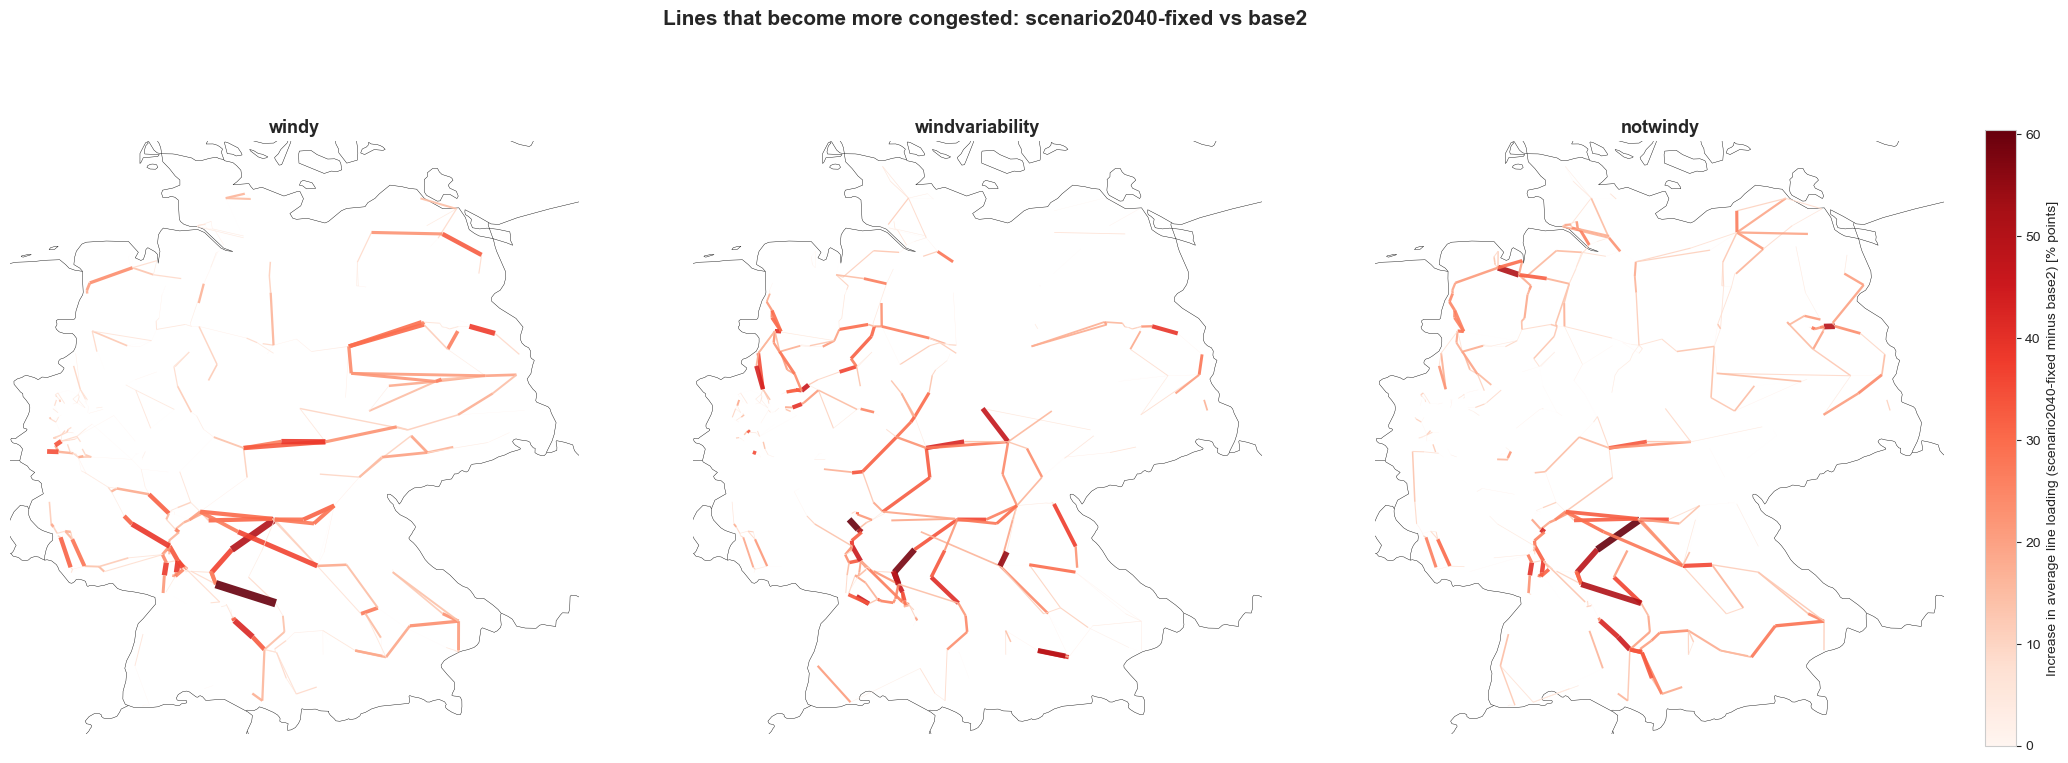

In [52]:
# Difference map: lines that become more congested in scenario2040-fixed relative to base2
# One subplot per wind condition, using n.plot like the grid congestion reference.

if 'line_stats_by_run' not in globals() or not line_stats_by_run:
    raise ValueError('line_stats_by_run is not available. Run the line congestion statistics cells first.')
if 'networks' not in globals() or not networks:
    raise ValueError('networks is not available. Run the network loading cell first.')

wind_conditions = ['windy', 'windvariability', 'notwindy']
base_scenario = 'base2'
compare_scenario = 'scenario2040'
compare_transmission = 'fixed'


def _normalize_run_metadata(run_key):
    """Return (scenario_name, transmission_setting, wind_condition) for a run key."""
    if 'split_network_name' in globals():
        try:
            scenario_name, transmission_setting, wind_condition = split_network_name(run_key)
            return str(scenario_name), str(transmission_setting), str(wind_condition)
        except Exception:
            pass

    if isinstance(run_key, tuple) and len(run_key) == 3:
        scenario_name, wind_condition, transmission_setting = run_key
        return str(scenario_name), str(transmission_setting), str(wind_condition)

    return str(run_key), 'fixed', ''


def _collect_line_stats(target_scenario, target_wind, target_transmission='fixed'):
    frames = []
    for run_key, stats in line_stats_by_run.items():
        if stats is None or stats.empty:
            continue
        if 'line_id' not in stats.columns or 'average_loading_pct' not in stats.columns:
            continue

        scenario_name, transmission_setting, wind_condition = _normalize_run_metadata(run_key)
        if (
            scenario_name == target_scenario
            and transmission_setting == target_transmission
            and wind_condition == target_wind
        ):
            frame = stats.copy()
            frame['scenario_name'] = scenario_name
            frame['transmission_setting'] = transmission_setting
            frame['wind_condition'] = wind_condition
            frames.append(frame)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


def _get_network_for_run(target_scenario, target_wind, target_transmission='fixed'):
    for run_key, network in networks.items():
        scenario_name, transmission_setting, wind_condition = _normalize_run_metadata(run_key)
        if (
            scenario_name == target_scenario
            and transmission_setting == target_transmission
            and wind_condition == target_wind
        ):
            return network
    return None


fig, axes = plt.subplots(1, len(wind_conditions), figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
if len(wind_conditions) == 1:
    axes = [axes]

comparison_rows = []
max_delta_global = 0.0

for wind_condition in wind_conditions:
    base_df = _collect_line_stats(base_scenario, wind_condition, compare_transmission)
    compare_df = _collect_line_stats(compare_scenario, wind_condition, compare_transmission)

    if base_df.empty or compare_df.empty:
        comparison_rows.append((wind_condition, pd.DataFrame(), None))
        continue

    merged = base_df[['line_id', 'average_loading_pct']].merge(
        compare_df[['line_id', 'average_loading_pct']],
        on='line_id',
        how='inner',
        suffixes=('_base2', '_scenario2040_fixed'),
    )

    if merged.empty:
        comparison_rows.append((wind_condition, pd.DataFrame(), None))
        continue

    merged['loading_delta_pct'] = merged['average_loading_pct_scenario2040_fixed'] - merged['average_loading_pct_base2']
    merged = merged[merged['loading_delta_pct'] > 0].copy()
    if merged.empty:
        comparison_rows.append((wind_condition, pd.DataFrame(), None))
        continue

    merged = merged.sort_values('loading_delta_pct', ascending=False)
    max_delta_global = max(max_delta_global, float(merged['loading_delta_pct'].max()))
    comparison_rows.append((wind_condition, merged, _get_network_for_run(compare_scenario, wind_condition, compare_transmission)))

if max_delta_global <= 0:
    for ax, wind_condition in zip(axes, wind_conditions):
        ax.text(0.5, 0.5, f'No positive differences\nfor {wind_condition}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(wind_condition, fontsize=13, fontweight='bold')
        ax.set_axis_off()
    print('No positive congestion differences found for the requested comparison.')
else:
    line_mappable = plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=0.0, vmax=max_delta_global),
        cmap=plt.get_cmap('Reds'),
    )
    line_mappable.set_array([])

    for ax, (wind_condition, merged, compare_network) in zip(axes, comparison_rows):
        if merged.empty or compare_network is None:
            ax.text(0.5, 0.5, f'No matching data\nfor {wind_condition}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(wind_condition, fontsize=13, fontweight='bold')
            ax.set_axis_off()
            continue

        delta_series = merged.set_index('line_id')['loading_delta_pct']
        positive_delta = pd.Series(0.0, index=compare_network.lines.index)
        positive_delta.loc[positive_delta.index.intersection(delta_series.index)] = delta_series.reindex(positive_delta.index.intersection(delta_series.index)).fillna(0.0)
        positive_delta = positive_delta.clip(lower=0.0)

        line_widths = positive_delta / max_delta_global * 6.0
        if line_widths.max() <= 0:
            ax.text(0.5, 0.5, f'No positive differences\nfor {wind_condition}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(wind_condition, fontsize=13, fontweight='bold')
            ax.set_axis_off()
            continue

        compare_network.plot(
            ax=ax,
            geomap=True,
            title=f'{wind_condition}',
            bus_sizes=0.005,
            bus_alpha=0.0,
            line_colors=positive_delta,
            line_cmap='Reds',
            line_width=line_widths,
            line_alpha=0.9,
            link_width=0,
            link_alpha=0.0,
        )
        ax.set_title(wind_condition, fontsize=13, fontweight='bold')

    cbar = fig.colorbar(line_mappable, ax=list(axes), orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label('Increase in average line loading (scenario2040-fixed minus base2) [% points]')
    fig.suptitle(
        'Lines that become more congested: scenario2040-fixed vs base2',
        fontsize=15,
        fontweight='bold',
        y=1.03,
    )
    fig.tight_layout(rect=[0, 0, 0.96, 0])
    plt.show()
